In [ ]:

# Step 1 — Install and import
!pip install pandas-datareader
import pandas_datareader.data as web
import pandas as pd

# Step 2 — Define time period
start = "2000-01-01"
end = "2023-12-31"

# Step 3 — Download data
gdp_raw = web.DataReader("CLVMNACSCAB1GQDE", "fred", start, end)
bci_raw = web.DataReader("BSCICP03DEM665S", "fred", start, end)

# Step 4 — Convert GDP to growth rate
gdp_growth = gdp_raw.pct_change() * 100
gdp_growth.columns = ["gdp_growth"]

# Step 5 — Rename BCI column
bci_raw.columns = ["bci"]

# Step 6 — Resample BCI from monthly to quarterly
bci_quarterly = bci_raw.resample("QE").mean()

# Step 7 — Align date indexes so they match
bci_quarterly.index = bci_quarterly.index.to_period("Q").to_timestamp()
gdp_growth.index = gdp_growth.index.to_period("Q").to_timestamp()

# Step 8 — Merge into one table
df = pd.merge(gdp_growth, bci_quarterly, left_index=True, right_index=True)
df = df.dropna()
print(df.shape)
print(df.head())
df.to_csv("germany_data.csv")
print("CSV saved!")

(95, 2)
            gdp_growth         bci
DATE                              
2000-04-01    0.797749  100.798433
2000-07-01    0.073049  100.952967
2000-10-01   -0.425845  100.888100
2001-01-01    2.123041  100.272857
2001-04-01   -0.251252   99.362873
CSV saved!


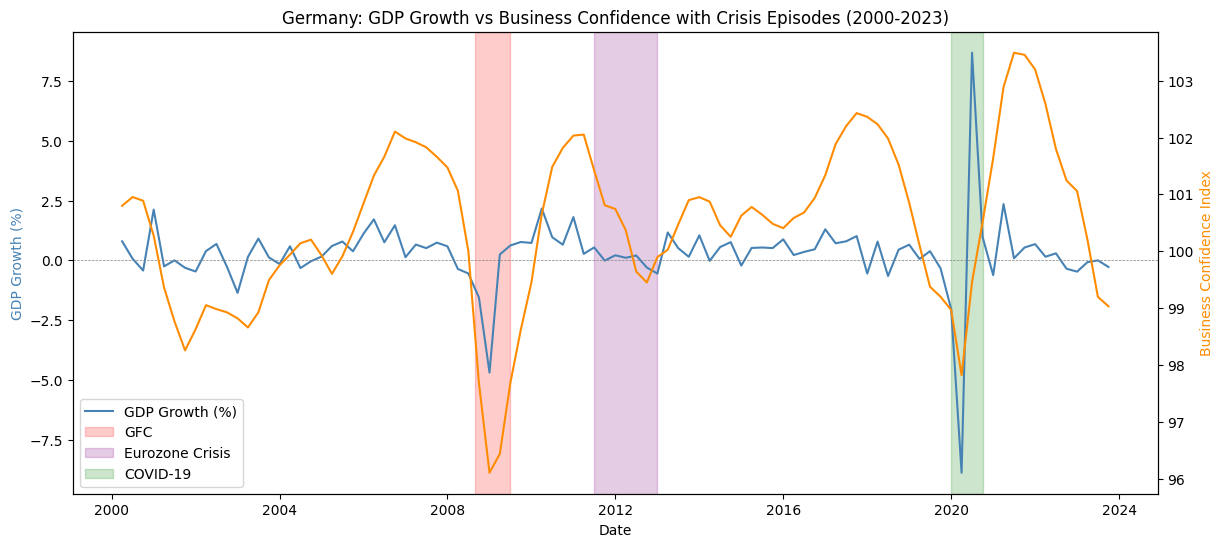

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot GDP growth on left axis
ax1.plot(df.index, df["gdp_growth"], color="steelblue", label="GDP Growth (%)")
ax1.set_ylabel("GDP Growth (%)", color="steelblue")
ax1.set_xlabel("Date")
ax1.axhline(0, color="grey", linestyle="--", linewidth=0.5)

# Create second y-axis for BCI
ax2 = ax1.twinx()
ax2.plot(df.index, df["bci"], color="darkorange", label="BCI")
ax2.set_ylabel("Business Confidence Index", color="darkorange")

# Annotate the three crises
ax1.axvspan("2008-09-01", "2009-06-30", alpha=0.2, color="red", label="GFC")
ax1.axvspan("2011-07-01", "2012-12-31", alpha=0.2, color="purple", label="Eurozone Crisis")
ax1.axvspan("2020-01-01", "2020-09-30", alpha=0.2, color="green", label="COVID-19")

plt.title("Germany: GDP Growth vs Business Confidence with Crisis Episodes (2000-2023)")
ax1.legend(loc="lower left")
plt.show()

                  gdp_growth       bci  gdp_next_quarter
gdp_growth          1.000000  0.327253         -0.154645
bci                 0.327253  1.000000          0.095201
gdp_next_quarter   -0.154645  0.095201          1.000000


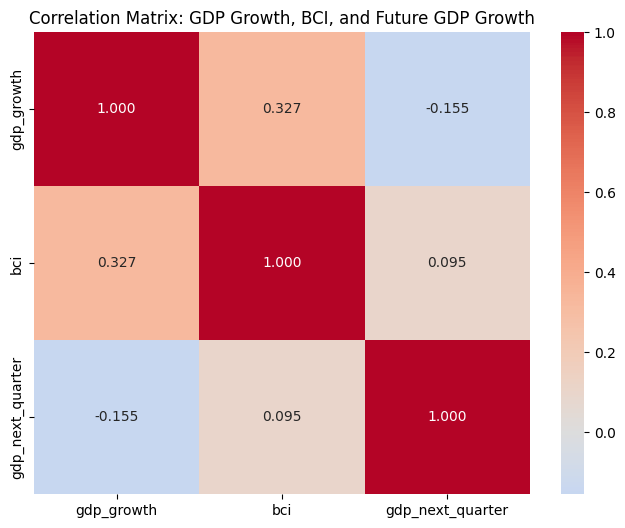

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a lagged GDP column — GDP one quarter into the future
df["gdp_next_quarter"] = df["gdp_growth"].shift(-1)

# Calculate the full correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

# Visualise as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Correlation Matrix: GDP Growth, BCI, and Future GDP Growth")
plt.show()

In [ ]:
df.to_csv("germany_data.csv")

from google.colab import files
files.download("germany_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(42)

# Number of synthetic observations (quarters)
n = 100

# True parameters we're baking into the data
true_beta_0 = 0.2      # constant
true_beta_1 = 0.4      # autocorrelation in GDP
true_beta_S = 0.05     # sentiment impact coefficient
sigma = 0.6            # noise level

# Generate synthetic BCI series with autocorrelation around 100
bci_sim = np.zeros(n)
bci_sim[0] = 100
for t in range(1, n):
    bci_sim[t] = 100 + 0.8 * (bci_sim[t-1] - 100) + np.random.normal(0, 1)

# Generate synthetic GDP growth using our equation
gdp_sim = np.zeros(n)
gdp_sim[0] = 0.5
for t in range(1, n):
    gdp_sim[t] = (
        true_beta_0
        + true_beta_1 * gdp_sim[t-1]
        + true_beta_S * (bci_sim[t] - 100)
        + np.random.normal(0, sigma)
    )

# Build into a DataFrame
synthetic_df = pd.DataFrame({
    "gdp_growth_sim": gdp_sim,
    "bci_sim": bci_sim
})

print(synthetic_df.head())
print(synthetic_df.describe())

   gdp_growth_sim     bci_sim
0        0.500000  100.000000
1        0.284083  100.496714
2       -0.522634  100.259107
3       -0.218692  100.854974
4        0.017245  102.207009
       gdp_growth_sim     bci_sim
count      100.000000  100.000000
mean         0.327411   99.513982
std          0.586674    1.464648
min         -0.788458   96.358216
25%         -0.082931   98.327226
50%          0.283409   99.574883
75%          0.617355  100.500825
max          1.940313  102.930308


In [ ]:
import statsmodels.api as sm

# Create lagged GDP for synthetic data
synthetic_df["gdp_lag"] = synthetic_df["gdp_growth_sim"].shift(1)
synthetic_df["bci_centered"] = synthetic_df["bci_sim"] - 100
synthetic_df = synthetic_df.dropna()

# Define dependent and independent variables
y_sim = synthetic_df["gdp_growth_sim"]
X_sim = synthetic_df[["gdp_lag", "bci_centered"]]
X_sim = sm.add_constant(X_sim)

# Run OLS regression
model_sim = sm.OLS(y_sim, X_sim).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:         gdp_growth_sim   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     4.521
Date:                Mon, 11 May 2026   Prob (F-statistic):             0.0133
Time:                        13:02:28   Log-Likelihood:                -83.181
No. Observations:                  99   AIC:                             172.4
Df Residuals:                      96   BIC:                             180.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2330      0.069      3.386   

In [ ]:
# Prepare real Germany data for regression
df["gdp_lag"] = df["gdp_growth"].shift(1)
df["bci_centered"] = df["bci"] - 100
df_reg = df.dropna()

# Set up dependent and independent variables
y_real = df_reg["gdp_growth"]
X_real = df_reg[["gdp_lag", "bci_centered"]]
X_real = sm.add_constant(X_real)

# Run OLS regression on real data
model_real = sm.OLS(y_real, X_real).fit()
print(model_real.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     10.58
Date:                Mon, 11 May 2026   Prob (F-statistic):           7.44e-05
Time:                        13:02:28   Log-Likelihood:                -163.43
No. Observations:                  93   AIC:                             332.9
Df Residuals:                      90   BIC:                             340.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1381      0.156      0.884   

In [ ]:
import statsmodels.api as sm

# Prepare real Germany data for regression
df["gdp_lag"] = df["gdp_growth"].shift(1)
df["bci_centered"] = df["bci"] - 100
df_reg = df.dropna()

# Set up dependent and independent variables
y_real = df_reg["gdp_growth"]
X_real = df_reg[["gdp_lag", "bci_centered"]]
X_real = sm.add_constant(X_real)

# Robust standard errors (HC3) to address non-normal residuals
model_real_robust = sm.OLS(y_real, X_real).fit(cov_type='HC3')
print(model_real_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     3.033
Date:                Mon, 11 May 2026   Prob (F-statistic):             0.0531
Time:                        13:02:28   Log-Likelihood:                -163.43
No. Observations:                  93   AIC:                             332.9
Df Residuals:                      90   BIC:                             340.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1381      0.273      0.506   

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Use the same X and y as the OLS regression (without the constant column)
X_rf = df_reg[["gdp_lag", "bci_centered"]]
y_rf = df_reg["gdp_growth"]

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_rf, y_rf)

# Generate predictions
rf_predictions = rf_model.predict(X_rf)

# Evaluate Random Forest performance
rf_r2 = r2_score(y_rf, rf_predictions)
rf_mse = mean_squared_error(y_rf, rf_predictions)

# Get OLS predictions for fair comparison
ols_predictions = model_real.predict(X_real)
ols_r2 = r2_score(y_real, ols_predictions)
ols_mse = mean_squared_error(y_real, ols_predictions)

# Print comparison
print("=== MODEL COMPARISON ===")
print(f"OLS R-squared:           {ols_r2:.4f}")
print(f"Random Forest R-squared: {rf_r2:.4f}")
print(f"OLS MSE:                 {ols_mse:.4f}")
print(f"Random Forest MSE:       {rf_mse:.4f}")
print()
print("=== FEATURE IMPORTANCE (Random Forest) ===")
for feature, importance in zip(X_rf.columns, rf_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

=== MODEL COMPARISON ===
OLS R-squared:           0.1904
Random Forest R-squared: 0.7842
OLS MSE:                 1.9676
Random Forest MSE:       0.5245

=== FEATURE IMPORTANCE (Random Forest) ===
gdp_lag: 0.6736
bci_centered: 0.3264


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

# Set up time-series cross-validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

# Cross-validate Random Forest
rf_cv_scores = cross_val_score(rf_model, X_rf, y_rf, cv=tscv, scoring="r2")

# Cross-validate OLS using sklearn's LinearRegression for fair comparison
from sklearn.linear_model import LinearRegression
ols_cv_model = LinearRegression()
ols_cv_scores = cross_val_score(ols_cv_model, X_rf, y_rf, cv=tscv, scoring="r2")

# Print results
print("=== CROSS-VALIDATED MODEL COMPARISON ===")
print(f"OLS CV R-squared (5-fold mean):           {np.mean(ols_cv_scores):.4f}")
print(f"Random Forest CV R-squared (5-fold mean): {np.mean(rf_cv_scores):.4f}")
print()
print(f"OLS CV scores per fold:           {[f'{s:.3f}' for s in ols_cv_scores]}")
print(f"Random Forest CV scores per fold: {[f'{s:.3f}' for s in rf_cv_scores]}")

=== CROSS-VALIDATED MODEL COMPARISON ===
OLS CV R-squared (5-fold mean):           -0.0658
Random Forest CV R-squared (5-fold mean): -0.2976

OLS CV scores per fold:           ['-0.172', '0.288', '0.109', '-0.629', '0.075']
Random Forest CV scores per fold: ['-0.714', '0.144', '-0.472', '-0.525', '0.078']


In [ ]:
import plotly.express as px

# Generate fitted values from the OLS regression
fitted_values = model_real.predict(X_real)

# Build a DataFrame for plotting (long format works best with Plotly)
plot_df = pd.DataFrame({
    "Date": df_reg.index,
    "Actual GDP Growth": df_reg["gdp_growth"].values,
    "Fitted GDP Growth": fitted_values.values
})

# Reshape from wide to long so Plotly can colour by series
plot_long = plot_df.melt(
    id_vars="Date",
    value_vars=["Actual GDP Growth", "Fitted GDP Growth"],
    var_name="Series",
    value_name="GDP Growth (%)"
)

# Build the line chart
fig = px.line(
    plot_long,
    x="Date",
    y="GDP Growth (%)",
    color="Series",
    title="Germany: Actual vs Fitted GDP Growth (OLS Nowcasting Model, 2000-2023)",
    color_discrete_map={
        "Actual GDP Growth": "steelblue",
        "Fitted GDP Growth": "darkorange"
    }
)

# Add zero line for reference
fig.add_hline(y=0, line_dash="dash", line_color="grey")

# Show the chart
fig.show()